Symbolic AI Concepts (Part 1)
## Symbolic Reasoning Foundations for Neural Researchers

This notebook is for people who are strong in **deep learning** but want the minimum set of **symbolic reasoning** skills needed for Neuro‑Symbolic AI.

**Key idea:** symbolic methods let you represent **structure, constraints, and meaning** explicitly (often with guarantees), while neural methods excel at **perception, generalization, and pattern learning**.

### What this notebook covers
- Propositional Logic
- First‑Order Logic (predicates, quantifiers, rules)
- Horn clauses & rule‑based reasoning

## 1) Propositional Logic

**Propositional logic** works with statements (propositions) that are either **True** or **False**.

- Variables: `P`, `Q`, `R` … (booleans)
- Operators: `AND (∧)`, `OR (∨)`, `NOT (¬)`, `IMPLIES (→)`

### Why neural folks should care
In neuro‑symbolic systems, propositional logic is often used for **policy checks** and **guardrails**:

- “If the data is PII, then encryption must be enabled.”
- “If the model is in production, then evaluation must have passed.”
- “If user is not authorized, deny tool execution.”

These are crisp **constraints**—not “likely true”, but *must be true*.

### Example: a simple security policy
Policy:
> If a request touches PII, it must be encrypted.  
Formally:
> `PII → Encrypted`

We’ll test this policy across all possible combinations and see where it fails.


In [ ]:
from itertools import product
from dataclasses import dataclass

def hr(title: str):
    print("\n" + "="*80)
    print(title)
    print("="*80)

hr("Propositional Logic: policy check for PII -> Encrypted")

def implies(a: bool, b: bool) -> bool:
    # a -> b is equivalent to (not a) or b
    return (not a) or b

# Variables in our tiny policy world
# PII: does the request contain personally identifiable information?
# ENC: is encryption enabled?
for PII, ENC in product([False, True], repeat=2):
    ok = implies(PII, ENC)
    status = "✅ OK" if ok else "❌ VIOLATION"
    print(f"PII={PII:<5} Encrypted={ENC:<5}  Policy(PII -> Encrypted): {status}")

print("\nInterpretation:")
print("- The only failing case is when PII=True but Encrypted=False.")
print("- If PII=False, the policy doesn't require encryption (it may still be enabled).")


### Tautologies (always true) vs constraints (sometimes violated)

Sometimes you check whether a formula is **always true** (a tautology)—useful for verifying rule transformations.
Example tautology:
> `(P ∧ Q) → P`

This is always true because if both `P` and `Q` are true, then `P` is definitely true.


In [ ]:
hr("Truth table: (P AND Q) -> P  (a tautology)")

for P, Q in product([False, True], repeat=2):
    expr = implies(P and Q, P)
    print(f"P={P:<5} Q={Q:<5}  (P∧Q)->P = {expr}")


A logic statement is only False if the "If" part happens but the "Then" part fails; in all other cases, it remains True.

**Example: Imagine a parent says**

"If you get an A in Math AND an A in Science, I will take you to get Ice Cream."

What happened: You got an A in Math, but you got a C in Science.

The Surprise: Your parent takes you to get Ice Cream anyway because they're in a good mood.

**Did the parent LIE?** No. They said what they would do if you got two A's. They didn't say what they would do if you failed. Because the "If" condition (Two A's) wasn't met, the parent can do whatever they want (Ice Cream or No Ice Cream) without being a liar.

**Real world Example**
(LicensedDoctor ∧ OnDuty) → LicensedDoctor

If both “licensed doctor” and “on duty” are true, then “licensed doctor” must be true,
Being “on duty” is irrelevant to proving they’re a doctor.

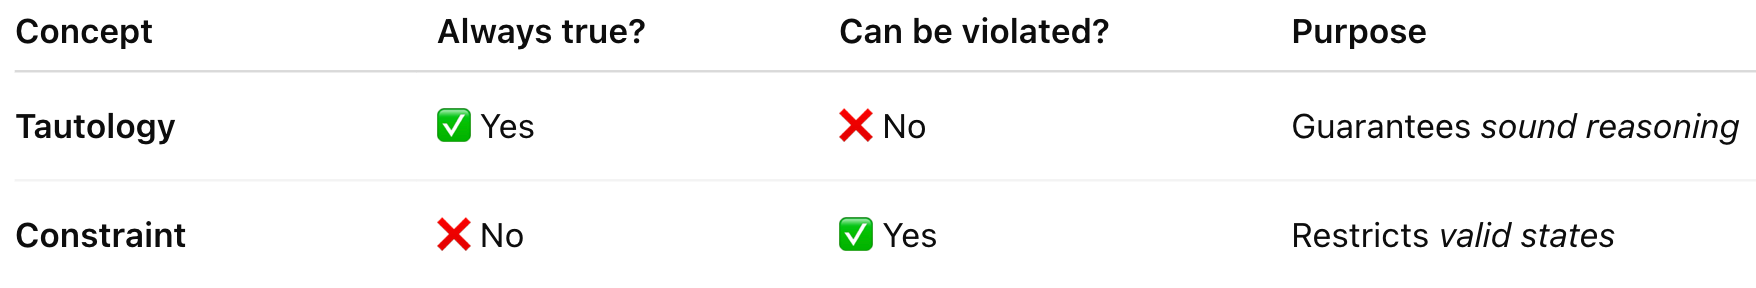

## 2) First‑Order Logic (FOL)

**First‑Order Logic** extends propositional logic with **objects** and **relationships**.

- **Objects**: `alice`, `document_12`, `cluster_A`
- **Predicates**: `Owns(alice, document_12)`, `IsPII(document_12)`
- **Variables**: `x`, `y`
- **Quantifiers**:
  - `∀x` (*for all x*)
  - `∃x` (*there exists x*)

### Why this matters
FOL is a natural language for “business rules” and “system invariants”.

Example compliance rule:
> For all documents `d`, if `d` is PII, then `d` must be encrypted.  
Formally:
> `∀d: IsPII(d) → Encrypted(d)`

Because we have a finite set of documents in our example, we can evaluate the rule by checking each one.


In [ ]:
hr("FOL (finite domain): ∀d IsPII(d) -> Encrypted(d)")

docs = ["doc_1", "doc_2", "doc_3"]

# Facts (knowledge base)
IsPII = {"doc_2", "doc_3"}         # doc_2 and doc_3 contain PII
Encrypted = {"doc_2"}              # only doc_2 is encrypted (doc_3 is not)

def is_pii(d): return d in IsPII
def encrypted(d): return d in Encrypted

violations = [d for d in docs if is_pii(d) and not encrypted(d)]

print("Documents:", docs)
print("PII docs:", IsPII)
print("Encrypted docs:", Encrypted)
print("\nRule violations (PII but not encrypted):", violations)

# A common symbolic step: derive obligations / fixes
fixes = [(d, "enable_encryption") for d in violations]
print("Suggested remediation actions:", fixes)


### Existential quantifier (∃) intuition

Example:
> “There exists a document that is PII.”  
Formally:
> `∃d: IsPII(d)`

On a finite domain, this just means “at least one element satisfies the predicate”.


In [ ]:
hr("Existential: ∃d IsPII(d)")

exists_pii = any(d in IsPII for d in docs)
print("∃d IsPII(d) ?", exists_pii)


## 3) Horn Clauses & Rule‑Based Reasoning

A **Horn clause** is a rule like:
> `A ∧ B ∧ ... ∧ K → H`

Where the conclusion `H` is a **single** atom. This form enables efficient inference engines (e.g., Datalog).

### Why this matters
Horn rules are great for **deriving structured facts** from raw facts:
- compute “grandparent” from “parent”
- compute “impacted service” from dependency edges
- compute “noncompliant resource” from policy facts

Below is a more “systems” flavored example: impact propagation.

Rule:
> `DependsOn(A, B) ∧ Down(B) → Impacted(A)`

If A depends on B, and B is down, then A is impacted.


In [ ]:
hr("Horn clause: derive impacted services from dependencies")

DependsOn = {
    ("frontend", "payments"),
    ("frontend", "search"),
    ("payments", "db"),
    ("search", "db"),
}
Down = {"db"}  # root outage

Impacted = set()

# Rule: DependsOn(A,B) & Down(B) -> Impacted(A)
for (A, B) in DependsOn:
    if B in Down:
        Impacted.add(A)

print("Down:", Down)
print("Directly impacted:", Impacted)

# Often you chain rules repeatedly to propagate impact upwards.
changed = True
while changed:
    changed = False
    for (A, B) in DependsOn:
        if B in Impacted and A not in Impacted:
            Impacted.add(A)
            changed = True

print("Transitively impacted:", Impacted)
print("\nInterpretation: a DB outage impacts search/payments, which then impacts frontend.")
